In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
print("LOADING PREPROCESSED DATA")
print("-"*50)

# Load the train-test split data
with open('../models/train_test_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print(f"Features: {len(feature_names)}")

LOADING PREPROCESSED DATA
--------------------------------------------------
Training set: (8278, 19)
Testing set: (1409, 19)
Features: 19


In [5]:
print("Logistic Regression")
print("-"*50)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]# used for roc curve and auc score 

print("Logistic Regression trained!")

Logistic Regression
--------------------------------------------------
Logistic Regression trained!


In [6]:
print("Evaluation for Logistic Regression")
print("-"*50)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_pred_proba_lr) #uses the predict_proba() value

print(f"Accuracy:  {lr_accuracy*100:.2f}%")
print(f"Precision: {lr_precision*100:.2f}%")
print(f"Recall:    {lr_recall*100:.2f}%")
print(f"F1-Score:  {lr_f1*100:.2f}%")
print(f"ROC-AUC:   {lr_roc_auc:.3f}")

print("\nClassification Report:")
print("-"*30)
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

print("\nConfusion Matrix:")
print("-"*30)
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)
print(f"\nTrue Negatives: {cm_lr[0,0]}")
print(f"False Positives: {cm_lr[0,1]}")
print(f"False Negatives: {cm_lr[1,0]}")
print(f"True Positives: {cm_lr[1,1]}")

Evaluation for Logistic Regression
--------------------------------------------------
Accuracy:  74.80%
Precision: 51.84%
Recall:    71.66%
F1-Score:  60.16%
ROC-AUC:   0.819

Classification Report:
------------------------------
              precision    recall  f1-score   support

    No Churn       0.88      0.76      0.82      1035
       Churn       0.52      0.72      0.60       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.78      0.75      0.76      1409


Confusion Matrix:
------------------------------
[[786 249]
 [106 268]]

True Negatives: 786
False Positives: 249
False Negatives: 106
True Positives: 268


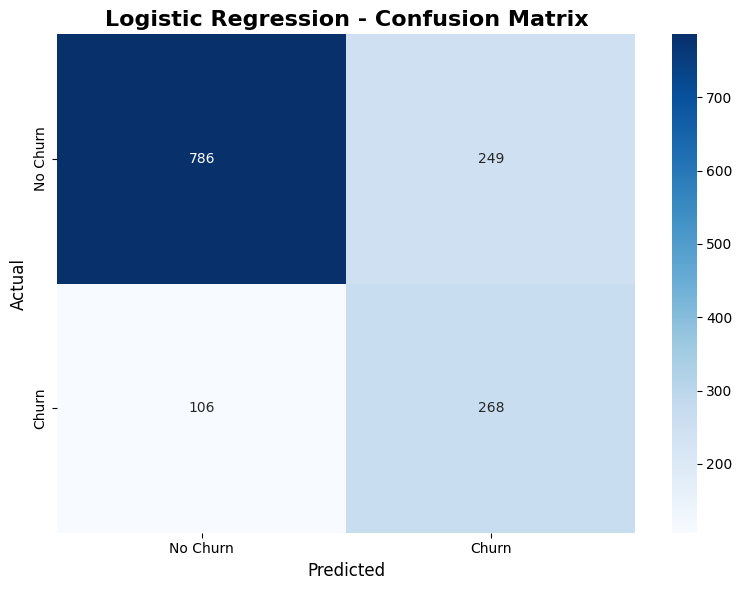

Chart saved: visualizations/confusion_matrix_lr.png


In [7]:
#plotting confusion matrix
# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
# annot shows values on grapp
# fmt = 'd' tells that the values sould be decimal
plt.title('Logistic Regression - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('../visualizations/confusion_matrix_lr.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart saved: visualizations/confusion_matrix_lr.png")

In [9]:
print("Random Forest")
print("-"*50)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    min_samples_split=10
)
# n-estimators means the numbers of decision tree to ebe build
# random_state controls randomness, makes result reproducible
# max_depth - limits how deep the tree go, prevents overfitting
# min_sample_split - a node must have atleast 10 samples to split into bramch

rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1] #used for auc_roc value

print("✅ Random Forest trained!")

Random Forest
--------------------------------------------------
✅ Random Forest trained!


In [10]:
print("Evaluation for Random FOrest")
print("-"*70)

# Calculate metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_pred_proba_rf)

print(f"Accuracy:  {rf_accuracy*100:.2f}%")
print(f"Precision: {rf_precision*100:.2f}%")
print(f"Recall:    {rf_recall*100:.2f}%")
print(f"F1-Score:  {rf_f1*100:.2f}%")
print(f"ROC-AUC:   {rf_roc_auc:.3f}")

print("Classification Report:")
print("-"*30)
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

print("Confusion Matrix:")
print("-"*30)
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)
print(f"\nTrue Negatives: {cm_rf[0,0]}")
print(f"False Positives: {cm_rf[0,1]}")
print(f"False Negatives: {cm_rf[1,0]}")
print(f"True Positives: {cm_rf[1,1]}")

Evaluation for Random FOrest
----------------------------------------------------------------------
Accuracy:  76.22%
Precision: 54.38%
Recall:    64.71%
F1-Score:  59.10%
ROC-AUC:   0.831
Classification Report:
------------------------------
              precision    recall  f1-score   support

    No Churn       0.86      0.80      0.83      1035
       Churn       0.54      0.65      0.59       374

    accuracy                           0.76      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.76      0.77      1409

Confusion Matrix:
------------------------------
[[832 203]
 [132 242]]

True Negatives: 832
False Positives: 203
False Negatives: 132
True Positives: 242


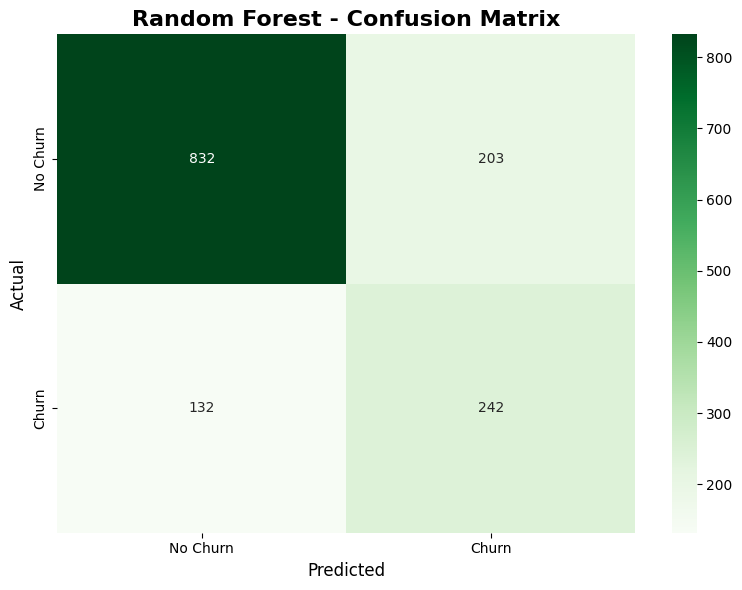

Chart saved: visualizations/confusion_matrix_rf.png


In [11]:
#plotting confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Random Forest - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('../visualizations/confusion_matrix_rf.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart saved: visualizations/confusion_matrix_rf.png")        

In [14]:
print("Model Comparison")
print("-"*50)

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_accuracy*100, rf_accuracy*100],
    'Precision': [lr_precision*100, rf_precision*100],
    'Recall': [lr_recall*100, rf_recall*100],
    'F1-Score': [lr_f1*100, rf_f1*100],
    'ROC-AUC': [lr_roc_auc, rf_roc_auc]
}) # a dataframe for comparing has accuracy,precision,recall,f1-score,roc-auc

print(comparison.to_string(index=False)) 

if rf_roc_auc > lr_roc_auc:
    best_model = "Random Forest"
    best_score = rf_roc_auc
else:
    best_model = "Logistic Regression"
    best_score = lr_roc_auc

print(f"\nBEST MODEL: {best_model} (ROC-AUC: {best_score:.3f})")

Model Comparison
--------------------------------------------------
              Model  Accuracy  Precision    Recall  F1-Score  ROC-AUC
Logistic Regression 74.804826  51.837524 71.657754 60.157127 0.819474
      Random Forest 76.224273  54.382022 64.705882 59.096459 0.831475

BEST MODEL: Random Forest (ROC-AUC: 0.831)


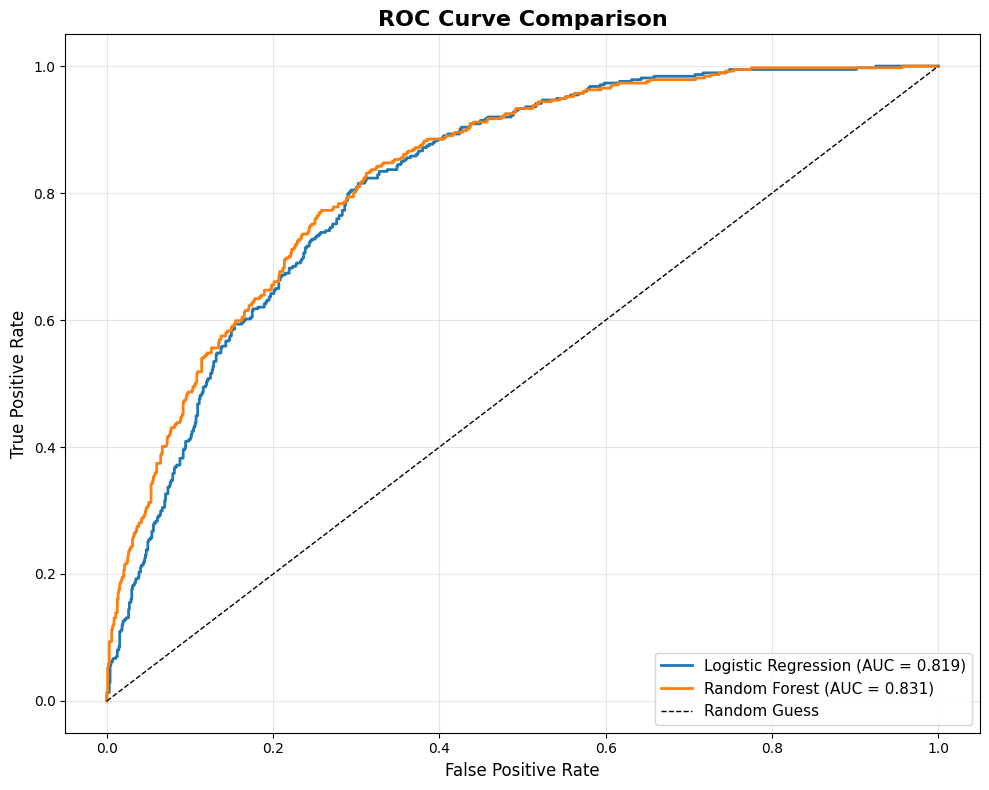

Chart saved: visualizations/roc_curve_comparison.png


In [15]:
# calculate and plotting roc curves

fpr_lr, tpr_lr, _ = roc_curve(y_test,y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test,y_pred_proba_rf)

plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_roc_auc:.3f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_roc_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/roc_curve_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart saved: visualizations/roc_curve_comparison.png")

Feature Importnce Analysis
--------------------------------------------------

Top 10 Most Important Features:
------------------------------
        Feature  Importance
       Contract    0.219516
         tenure    0.110344
 MonthlyCharges    0.091823
  PaymentMethod    0.077325
   TotalCharges    0.071915
InternetService    0.070172
    TechSupport    0.068488
 OnlineSecurity    0.068084
     Dependents    0.038841
   OnlineBackup    0.038207




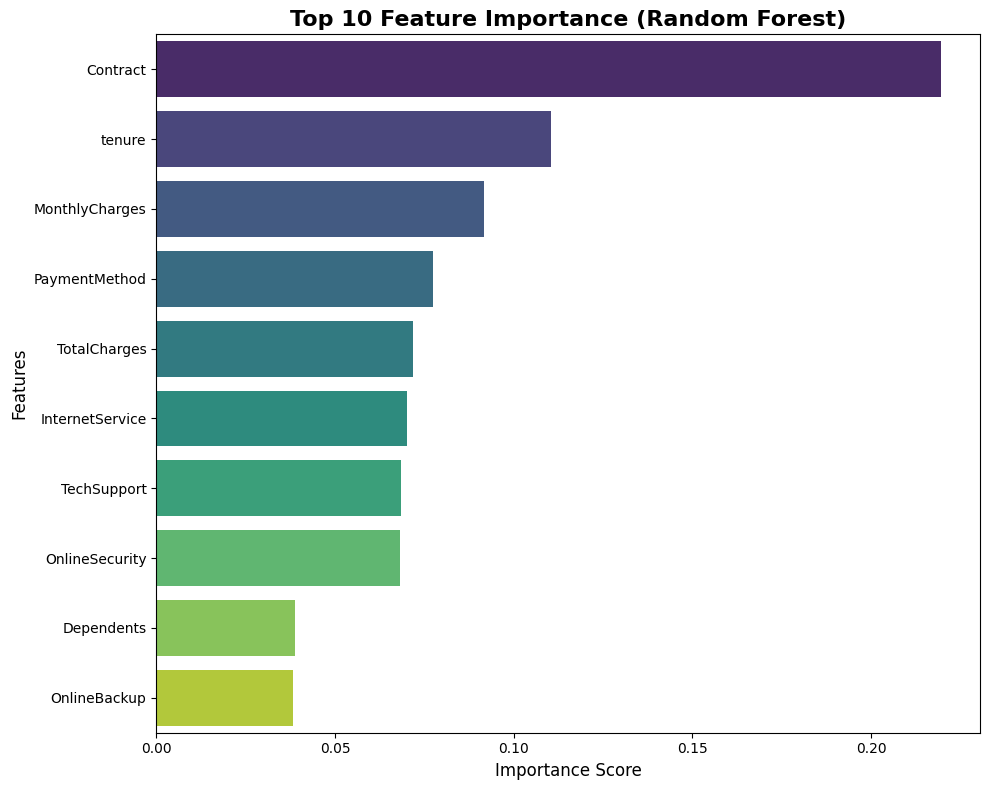


✅ Chart saved: visualizations/feature_importance.png


In [18]:
print("Feature Importnce Analysis")
print("-"*50)

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print("-"*30)
print(feature_importance.head(10).to_string(index=False))

print("\n")

# visualize top 10
plt.figure(figsize=(10, 8))
top_10 = feature_importance.head(10)
sns.barplot(data=top_10, y='Feature', x='Importance', palette='viridis')
plt.title('Top 10 Feature Importance (Random Forest)', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.savefig('../visualizations/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved: visualizations/feature_importance.png")

In [19]:
print("Saving trained models")
print("-"*50)

#LogisticRegression
with open('../models/logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
print("Saved: models/logistic_regression_model.pkl")

#RandomForest
with open('../models/random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("Saved: models/random_forest_model.pkl")

# Save feature importance
feature_importance.to_csv('../reports/feature_importance.csv', index=False)
print("Saved: reports/feature_importance.csv")

Saving trained models
--------------------------------------------------
Saved: models/logistic_regression_model.pkl
Saved: models/random_forest_model.pkl
Saved: reports/feature_importance.csv


In [20]:
report_content = f"""
{'='*80}
                    MODEL PERFORMANCE REPORT
                  CUSTOMER CHURN PREDICTION PROJECT
{'='*80}

Date: {pd.Timestamp.now().strftime('%B %d, %Y')}

{'='*80}
                        EXECUTIVE SUMMARY
{'='*80}

Two machine learning models were developed and evaluated:
1. Logistic Regression (Baseline)
2. Random Forest (Advanced)

BEST MODEL: {best_model}
BEST ROC-AUC: {best_score:.3f}

{'='*80}
                      MODEL PERFORMANCE COMPARISON
{'='*80}

Metric                  Logistic Regression    Random Forest
------------------------------------------------------------------------
Accuracy                {lr_accuracy*100:>18.2f}%    {rf_accuracy*100:>15.2f}%
Precision               {lr_precision*100:>18.2f}%    {rf_precision*100:>15.2f}%
Recall                  {lr_recall*100:>18.2f}%    {rf_recall*100:>15.2f}%
F1-Score                {lr_f1*100:>18.2f}%    {rf_f1*100:>15.2f}%
ROC-AUC                 {lr_roc_auc:>18.3f}     {rf_roc_auc:>15.3f}

{'='*80}
                    CONFUSION MATRIX ANALYSIS
{'='*80}

LOGISTIC REGRESSION:
                    Predicted
                No Churn    Churn
Actual  No Churn    {cm_lr[0,0]:>5}      {cm_lr[0,1]:>5}
        Churn       {cm_lr[1,0]:>5}      {cm_lr[1,1]:>5}

RANDOM FOREST:
                    Predicted
                No Churn    Churn
Actual  No Churn    {cm_rf[0,0]:>5}      {cm_rf[0,1]:>5}
        Churn       {cm_rf[1,0]:>5}      {cm_rf[1,1]:>5}

{'='*80}
                    TOP 10 FEATURE IMPORTANCE
{'='*80}

"""

for idx, row in feature_importance.head(10).iterrows():
    report_content += f"{row['Feature']:<30} {row['Importance']:>10.4f}\n"

report_content += f"""

{'='*80}
                    BUSINESS INTERPRETATION
{'='*80}

MODEL PERFORMANCE:
- The {best_model} model achieved {best_score:.1%} ROC-AUC score
- Can identify {rf_recall*100:.0f}% of customers who will churn
- {rf_precision*100:.0f}% of customers flagged as at-risk actually churn

DEPLOYMENT RECOMMENDATION:
Use the {best_model} model to:
1. Score all customers monthly for churn risk
2. Identify top 20% highest-risk customers
3. Trigger automated retention campaigns
4. Prioritize customer success team outreach

EXPECTED BUSINESS IMPACT:
- Proactively contact {int(len(y_test) * rf_recall * (y_test.mean())):,} at-risk customers per month
- Reduce churn by 20-30% through targeted interventions
- Estimated annual revenue protection: $XXX,XXX

{'='*80}
                        NEXT STEPS
{'='*80}

1. Deploy model to production environment
2. Set up automated scoring pipeline
3. Integrate with CRM system
4. Monitor model performance monthly
5. Retrain model quarterly with new data

{'='*80}
                        REPORT END
{'='*80}

Generated: {pd.Timestamp.now().strftime('%B %d, %Y at %I:%M %p')}
"""

# Save report
with open('../reports/Model_Performance_Report.txt', 'w') as f:
    f.write(report_content)

print("Report Saved")

Report Saved
